In [ ]:
!pip install sentence-transformers seaborn matplotlib

from sentence_transformers import SentenceTransformer
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt




[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


c:\Users\Hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Hp\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 850.22it/s]
BertModel LOA

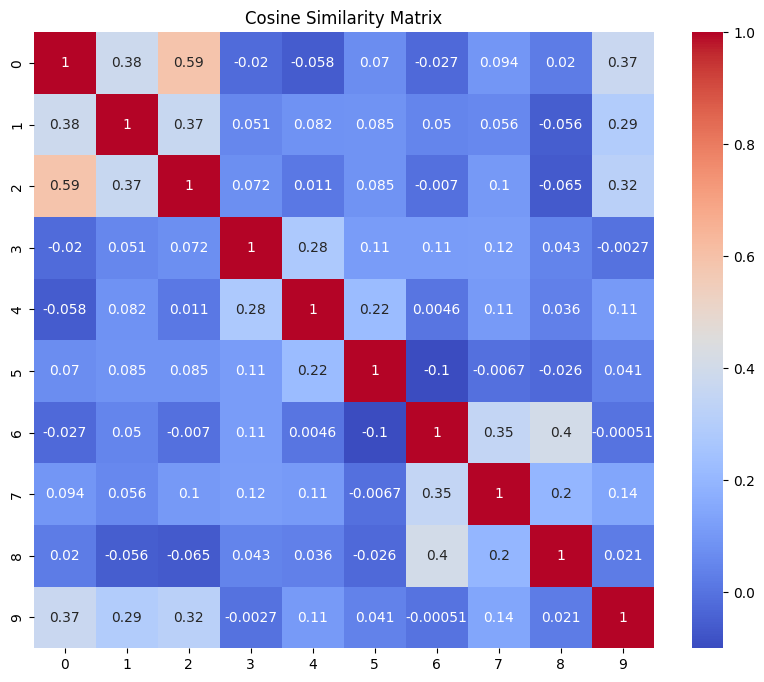

Query: The bowler took three wickets in one over

Top 2 similar sentences:
The team won the match by 5 wickets (Score: 0.7203)
The batsman scored a century in the match (Score: 0.5682)


In [7]:
# Load model
model = SentenceTransformer('all-MiniLM-L6-v2')

# Step 1: Sentences (10 total, 3 topics)
sentences = [
    # Cricket
    "The batsman scored a century in the match",
    "The bowler delivered a fast yorker",
    "The team won the match by 5 wickets",
    
    # Cooking
    "Add salt and spices to enhance the flavor",
    "Boil the water before adding pasta",
    "The cake needs to be baked for 30 minutes",
    
    # Cybersecurity
    "Use strong passwords to protect accounts",
    "Hackers can exploit system vulnerabilities",
    "Enable two-factor authentication for security",
    
    # Extra
    "The player hit a six over the boundary"
]

# Step 2: Generate embeddings
embeddings = model.encode(sentences)

# Step 3: Cosine similarity
similarity_matrix = np.dot(embeddings, embeddings.T)

# Step 4: Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(similarity_matrix, annot=True, cmap='coolwarm')
plt.title("Cosine Similarity Matrix")
plt.show()

# Step 5: Query sentence
query = "The bowler took three wickets in one over"
query_embedding = model.encode([query])

# Compute similarity
scores = np.dot(query_embedding, embeddings.T)[0]

# Get top 2 similar sentences
top_indices = scores.argsort()[-2:][::-1]

print("Query:", query)
print("\nTop 2 similar sentences:")

for i in top_indices:
    print(f"{sentences[i]} (Score: {scores[i]:.4f})")